In [1]:
import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [2]:
BASE_DIR = Path("/home/agrupa-lab/agrupa")
DB_PATH = BASE_DIR / "agrupa.sqlite"
OUTPUT_DIR = Path("/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs")

In [3]:
conn = sqlite3.connect(DB_PATH)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)
conn.close()

                  name
0              artwork
1             icon_tag
2      sqlite_sequence
3          source_file
4      artwork_tag_raw
5          artwork_tag
6          tag_closure
7        artwork_image
8      qwen_captions_m
9            figures_m
10  artwork_descriptor
11      artwork_sadcat


In [4]:
conn = sqlite3.connect(DB_PATH)

# Check structure and sample
sadcat = pd.read_sql("SELECT * FROM artwork_sadcat LIMIT 5", conn)
print(f"Columns: {list(sadcat.columns)}")
print(f"\nShape: {sadcat.shape}")
sadcat.head()
conn.close()

Columns: ['cat_no', 'n_descriptores_fila', 'n_en_diccionario_fila', 'cov_pct_global', 'cov_Sociability_dict_pct', 'cov_Morality_dict_pct', 'cov_Ability_dict_pct', 'cov_Agency_dict_pct', 'cov_health_dict_pct', 'cov_Status_dict_pct', 'cov_work_dict_pct', 'cov_Politics_dict_pct', 'cov_Religion_dict_pct', 'cov_beliefsother_dict_pct', 'cov_inhabitant_dict_pct', 'cov_country_dict_pct', 'cov_feeling_dict_pct', 'cov_relative_dict_pct', 'cov_clothing_dict_pct', 'cov_ordinariness_dict_pct', 'cov_bodpart_dict_pct', 'cov_bodprop_dict_pct', 'cov_skin_dict_pct', 'cov_bodcov_dict_pct', 'cov_beauty_dict_pct', 'cov_insults_dict_pct', 'cov_stem_dict_pct', 'cov_humanities_dict_pct', 'cov_art_dict_pct', 'cov_socialgroups_dict_pct', 'cov_Lacksknowledge_dict_pct', 'cov_fortune_dict_pct', 'cov_Sociability_dict_hi_pct', 'cov_Sociability_dict_lo_pct', 'cov_Morality_dict_hi_pct', 'cov_Morality_dict_lo_pct', 'cov_Ability_dict_hi_pct', 'cov_Ability_dict_lo_pct', 'cov_Agency_dict_hi_pct', 'cov_Agency_dict_lo_pct',

In [5]:
conn = sqlite3.connect(DB_PATH)

# Load full museum SADCAT scores
museum_scores = pd.read_sql("SELECT * FROM artwork_sadcat", conn)

# Load artwork metadata to join
artwork = pd.read_sql("SELECT cat_no, is_fauna, is_religious, century FROM artwork", conn)

conn.close()

# Merge with metadata
museum_scores = museum_scores.merge(artwork, on='cat_no', how='left')

print(f"Total artworks with museum SADCAT scores: {len(museum_scores)}")
print(f"Missing warmth scores: {museum_scores['dirmean_Warmth'].isna().sum()}")
print(f"Missing competence scores: {museum_scores['dirmean_Competence'].isna().sum()}")
print(f"\nMean global coverage: {museum_scores['cov_pct_global'].mean():.2f}%")

print(f"\nWarmth score summary:")
print(museum_scores['dirmean_Warmth'].describe())
print(f"\nCompetence score summary:")
print(museum_scores['dirmean_Competence'].describe())

Total artworks with museum SADCAT scores: 6888
Missing warmth scores: 1574
Missing competence scores: 2148

Mean global coverage: 7.31%

Warmth score summary:
count    5314.000000
mean        0.321857
std         0.606270
min        -1.000000
25%         0.000000
50%         0.357143
75%         1.000000
max         1.000000
Name: dirmean_Warmth, dtype: float64

Competence score summary:
count    4740.000000
mean        0.756407
std         0.363560
min        -1.000000
25%         0.619048
50%         0.904762
75%         1.000000
max         1.000000
Name: dirmean_Competence, dtype: float64


In [6]:
conn = sqlite3.connect(DB_PATH)
artwork_tags = pd.read_sql("""
    SELECT at.cat_no, it.tag_id, it.name, it.slug
    FROM artwork_tag at
    INNER JOIN icon_tag it ON at.tag_id = it.tag_id
""", conn)
conn.close()

# Define same groups as before
elite_ids    = [402, 403, 406, 407, 408, 409]
nonelite_ids = [358, 359, 360, 361, 364, 369, 370, 371, 372, 373, 376, 377, 380]
predatory_ids    = [206, 205, 208, 202, 216, 204, 194]
domesticated_ids = [217, 178, 215, 179, 176, 173, 182, 192]

elite_cats       = artwork_tags[artwork_tags['tag_id'].isin(elite_ids)]['cat_no'].unique()
nonelite_cats    = artwork_tags[artwork_tags['tag_id'].isin(nonelite_ids)]['cat_no'].unique()
predatory_cats   = artwork_tags[artwork_tags['tag_id'].isin(predatory_ids)]['cat_no'].unique()
domesticated_cats = artwork_tags[artwork_tags['tag_id'].isin(domesticated_ids)]['cat_no'].unique()

elite_scores_m       = museum_scores[museum_scores['cat_no'].isin(elite_cats)]
nonelite_scores_m    = museum_scores[museum_scores['cat_no'].isin(nonelite_cats)]
predatory_scores_m   = museum_scores[museum_scores['cat_no'].isin(predatory_cats)]
domesticated_scores_m = museum_scores[museum_scores['cat_no'].isin(domesticated_cats)]

print(f"Elite:        {len(elite_scores_m)}")
print(f"Non-Elite:    {len(nonelite_scores_m)}")
print(f"Predatory:    {len(predatory_scores_m)}")
print(f"Domesticated: {len(domesticated_scores_m)}")

Elite:        1080
Non-Elite:    160
Predatory:    168
Domesticated: 1469


In [7]:
# H1a — Elite vs Non-Elite Competence
elite_comp_m = elite_scores_m['dirmean_Competence'].dropna()
nonelite_comp_m = nonelite_scores_m['dirmean_Competence'].dropna()
elite_warm_m = elite_scores_m['dirmean_Warmth'].dropna()
nonelite_warm_m = nonelite_scores_m['dirmean_Warmth'].dropna()

t_comp, p_comp = stats.ttest_ind(elite_comp_m, nonelite_comp_m)
t_warm, p_warm = stats.ttest_ind(nonelite_warm_m, elite_warm_m)

print("=== H1a: Elite vs Non-Elite Competence ===")
print(f"Elite:     mean={elite_comp_m.mean():.3f}, std={elite_comp_m.std():.3f}, n={len(elite_comp_m)}")
print(f"Non-Elite: mean={nonelite_comp_m.mean():.3f}, std={nonelite_comp_m.std():.3f}, n={len(nonelite_comp_m)}")
print(f"t={t_comp:.3f}, p={p_comp:.4f}")
if p_comp < 0.05 and elite_comp_m.mean() > nonelite_comp_m.mean():
    print("→ H1a SUPPORTED ✓")
else:
    print("→ H1a NOT SUPPORTED")

print("\n=== H1b: Non-Elite vs Elite Warmth ===")
print(f"Elite:     mean={elite_warm_m.mean():.3f}, std={elite_warm_m.std():.3f}, n={len(elite_warm_m)}")
print(f"Non-Elite: mean={nonelite_warm_m.mean():.3f}, std={nonelite_warm_m.std():.3f}, n={len(nonelite_warm_m)}")
print(f"t={t_warm:.3f}, p={p_warm:.4f}")
if p_warm < 0.05 and nonelite_warm_m.mean() > elite_warm_m.mean():
    print("→ H1b SUPPORTED ✓")
else:
    print("→ H1b NOT SUPPORTED")

# H2a — Predatory vs Domesticated
pred_comp_m = predatory_scores_m['dirmean_Competence'].dropna()
dom_comp_m  = domesticated_scores_m['dirmean_Competence'].dropna()
pred_warm_m = predatory_scores_m['dirmean_Warmth'].dropna()
dom_warm_m  = domesticated_scores_m['dirmean_Warmth'].dropna()

t_comp2, p_comp2 = stats.ttest_ind(pred_comp_m, dom_comp_m)
t_warm2, p_warm2 = stats.ttest_ind(pred_warm_m, dom_warm_m)

print("\n=== H2a: Predatory vs Domesticated ===")
print(f"Predatory:    competence={pred_comp_m.mean():.3f}, warmth={pred_warm_m.mean():.3f}")
print(f"Domesticated: competence={dom_comp_m.mean():.3f}, warmth={dom_warm_m.mean():.3f}")
print(f"Competence: t={t_comp2:.3f}, p={p_comp2:.4f}")
print(f"Warmth:     t={t_warm2:.3f}, p={p_warm2:.4f}")

if p_comp2 < 0.05 and pred_comp_m.mean() > dom_comp_m.mean():
    print("→ H2a Competence SUPPORTED ✓")
else:
    print("→ H2a Competence NOT SUPPORTED")

if p_warm2 < 0.05 and pred_warm_m.mean() < dom_warm_m.mean():
    print("→ H2a Warmth SUPPORTED ✓")
else:
    print("→ H2a Warmth NOT SUPPORTED")

# H2b — Domesticated cluster
print("\n=== H2b: Domesticated Animals Position ===")
overall_warm_m = museum_scores['dirmean_Warmth'].mean()
overall_comp_m = museum_scores['dirmean_Competence'].mean()
print(f"Domesticated warmth: {dom_warm_m.mean():.3f} vs Overall: {overall_warm_m:.3f}")
print(f"Domesticated competence: {dom_comp_m.mean():.3f} vs Overall: {overall_comp_m:.3f}")
if dom_warm_m.mean() > overall_warm_m and dom_comp_m.mean() < overall_comp_m:
    print("→ H2b SUPPORTED ✓")
elif dom_warm_m.mean() > overall_warm_m:
    print("→ H2b PARTIALLY SUPPORTED (high warmth confirmed, competence not low)")
else:
    print("→ H2b NOT SUPPORTED")

=== H1a: Elite vs Non-Elite Competence ===
Elite:     mean=0.774, std=0.309, n=852
Non-Elite: mean=0.742, std=0.337, n=97
t=0.969, p=0.3330
→ H1a NOT SUPPORTED

=== H1b: Non-Elite vs Elite Warmth ===
Elite:     mean=0.362, std=0.540, n=883
Non-Elite: mean=0.257, std=0.688, n=117
t=-1.913, p=0.0561
→ H1b NOT SUPPORTED

=== H2a: Predatory vs Domesticated ===
Predatory:    competence=0.664, warmth=0.124
Domesticated: competence=0.735, warmth=0.228
Competence: t=-1.920, p=0.0551
Warmth:     t=-1.804, p=0.0714
→ H2a Competence NOT SUPPORTED
→ H2a Warmth NOT SUPPORTED

=== H2b: Domesticated Animals Position ===
Domesticated warmth: 0.228 vs Overall: 0.322
Domesticated competence: 0.735 vs Overall: 0.756
→ H2b NOT SUPPORTED


In [8]:
print("=== Coverage Analysis ===")
print(f"\nElite coverage:        {elite_scores_m['cov_pct_global'].mean():.2f}%")
print(f"Non-Elite coverage:    {nonelite_scores_m['cov_pct_global'].mean():.2f}%")
print(f"Predatory coverage:    {predatory_scores_m['cov_pct_global'].mean():.2f}%")
print(f"Domesticated coverage: {domesticated_scores_m['cov_pct_global'].mean():.2f}%")
print(f"Overall coverage:      {museum_scores['cov_pct_global'].mean():.2f}%")

print("\n=== Missing Scores by Group ===")
print(f"Elite missing warmth:        {elite_scores_m['dirmean_Warmth'].isna().sum()} / {len(elite_scores_m)}")
print(f"Non-Elite missing warmth:    {nonelite_scores_m['dirmean_Warmth'].isna().sum()} / {len(nonelite_scores_m)}")
print(f"Predatory missing warmth:    {predatory_scores_m['dirmean_Warmth'].isna().sum()} / {len(predatory_scores_m)}")
print(f"Domesticated missing warmth: {domesticated_scores_m['dirmean_Warmth'].isna().sum()} / {len(domesticated_scores_m)}")

=== Coverage Analysis ===

Elite coverage:        7.17%
Non-Elite coverage:    7.11%
Predatory coverage:    7.33%
Domesticated coverage: 7.17%
Overall coverage:      7.31%

=== Missing Scores by Group ===
Elite missing warmth:        197 / 1080
Non-Elite missing warmth:    43 / 160
Predatory missing warmth:    29 / 168
Domesticated missing warmth: 359 / 1469


In [9]:
# Merge LLaVA and museum scores on cat_no
llava_scores = pd.read_csv(
    "/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/sadcat_scores_llava.csv"
)

# Merge both datasets
combined = llava_scores[['cat_no', 'warmth_score', 'competence_score']].merge(
    museum_scores[['cat_no', 'dirmean_Warmth', 'dirmean_Competence']],
    on='cat_no',
    how='inner'
)

combined.rename(columns={
    'warmth_score':       'llava_warmth',
    'competence_score':   'llava_competence',
    'dirmean_Warmth':     'museum_warmth',
    'dirmean_Competence': 'museum_competence'
}, inplace=True)

print(f"Artworks with both LLaVA and museum scores: {len(combined)}")
print(f"\nLLaVA:  warmth={combined['llava_warmth'].mean():.3f}, competence={combined['llava_competence'].mean():.3f}")
print(f"Museum: warmth={combined['museum_warmth'].mean():.3f}, competence={combined['museum_competence'].mean():.3f}")

# Drop NAs together for each dimension
warm_combined = combined[['llava_warmth', 'museum_warmth']].dropna()
comp_combined = combined[['llava_competence', 'museum_competence']].dropna()

print(f"\nPairs for warmth correlation:     {len(warm_combined)}")
print(f"Pairs for competence correlation: {len(comp_combined)}")

# H3a — Correlation
corr_warm, p_warm = stats.pearsonr(warm_combined['llava_warmth'], warm_combined['museum_warmth'])
corr_comp, p_comp = stats.pearsonr(comp_combined['llava_competence'], comp_combined['museum_competence'])

print(f"\n=== H3a: Correlation LLaVA vs Museum ===")
print(f"Warmth correlation:     r={corr_warm:.3f}, p={p_warm:.4f}")
print(f"Competence correlation: r={corr_comp:.3f}, p={p_comp:.4f}")

if p_warm < 0.05 and corr_warm > 0:
    print("→ H3a Warmth SUPPORTED ✓")
else:
    print("→ H3a Warmth NOT SUPPORTED")

if p_comp < 0.05 and corr_comp > 0:
    print("→ H3a Competence SUPPORTED ✓")
else:
    print("→ H3a Competence NOT SUPPORTED")

# H3b — Variance comparison (LLaVA should have lower variance)
print(f"\n=== H3b: Variance Comparison ===")
print(f"LLaVA warmth std:     {combined['llava_warmth'].std():.3f}")
print(f"Museum warmth std:    {combined['museum_warmth'].std():.3f}")
print(f"LLaVA competence std:  {combined['llava_competence'].std():.3f}")
print(f"Museum competence std: {combined['museum_competence'].std():.3f}")

lev_warm, p_lev_warm = stats.levene(
    warm_combined['llava_warmth'],
    warm_combined['museum_warmth']
)
lev_comp, p_lev_comp = stats.levene(
    comp_combined['llava_competence'],
    comp_combined['museum_competence']
)

print(f"\nLevene warmth:     stat={lev_warm:.3f}, p={p_lev_warm:.4f}")
print(f"Levene competence: stat={lev_comp:.3f}, p={p_lev_comp:.4f}")

if p_lev_warm < 0.05 and combined['llava_warmth'].std() < combined['museum_warmth'].std():
    print("→ H3b Warmth SUPPORTED: LLaVA has lower variance ✓")
elif p_lev_warm < 0.05:
    print("→ H3b Warmth NOT SUPPORTED: Museum has lower variance")
else:
    print("→ H3b Warmth: No significant variance difference")

if p_lev_comp < 0.05 and combined['llava_competence'].std() < combined['museum_competence'].std():
    print("→ H3b Competence SUPPORTED: LLaVA has lower variance ✓")
elif p_lev_comp < 0.05:
    print("→ H3b Competence NOT SUPPORTED: Museum has lower variance")
else:
    print("→ H3b Competence: No significant variance difference")

Artworks with both LLaVA and museum scores: 6115

LLaVA:  warmth=0.371, competence=0.732
Museum: warmth=0.320, competence=0.757

Pairs for warmth correlation:     4859
Pairs for competence correlation: 4421

=== H3a: Correlation LLaVA vs Museum ===
Warmth correlation:     r=0.055, p=0.0001
Competence correlation: r=0.012, p=0.4218
→ H3a Warmth SUPPORTED ✓
→ H3a Competence NOT SUPPORTED

=== H3b: Variance Comparison ===
LLaVA warmth std:     0.244
Museum warmth std:    0.594
LLaVA competence std:  0.255
Museum competence std: 0.353

Levene warmth:     stat=2525.405, p=0.0000
Levene competence: stat=70.998, p=0.0000
→ H3b Warmth SUPPORTED: LLaVA has lower variance ✓
→ H3b Competence SUPPORTED: LLaVA has lower variance ✓


In [10]:
# H3c — Differences vary across iconographic categories
combined_meta = combined.merge(
    artwork[['cat_no', 'is_fauna', 'is_religious']],
    on='cat_no',
    how='left'
)

# Calculate absolute difference between LLaVA and museum scores
combined_meta['warmth_diff'] = abs(combined_meta['llava_warmth'] - combined_meta['museum_warmth'])
combined_meta['comp_diff'] = abs(combined_meta['llava_competence'] - combined_meta['museum_competence'])

# Compare differences across categories
fauna = combined_meta[combined_meta['is_fauna'] == 1]
human = combined_meta[combined_meta['is_fauna'] == 0]

print("=== H3c: Differences by Iconographic Category ===")
print(f"\nFauna artworks:  n={len(fauna)}")
print(f"  Warmth diff:     {fauna['warmth_diff'].mean():.3f}")
print(f"  Competence diff: {fauna['comp_diff'].mean():.3f}")

print(f"\nHuman artworks:  n={len(human)}")
print(f"  Warmth diff:     {human['warmth_diff'].mean():.3f}")
print(f"  Competence diff: {human['comp_diff'].mean():.3f}")

t_warm_h3c, p_warm_h3c = stats.ttest_ind(
    fauna['warmth_diff'].dropna(),
    human['warmth_diff'].dropna()
)
t_comp_h3c, p_comp_h3c = stats.ttest_ind(
    fauna['comp_diff'].dropna(),
    human['comp_diff'].dropna()
)

print(f"\nWarmth diff t-test:     t={t_warm_h3c:.3f}, p={p_warm_h3c:.4f}")
print(f"Competence diff t-test: t={t_comp_h3c:.3f}, p={p_comp_h3c:.4f}")

if p_warm_h3c < 0.05:
    print("→ H3c Warmth SUPPORTED: differences vary across categories ✓")
else:
    print("→ H3c Warmth NOT SUPPORTED")

if p_comp_h3c < 0.05:
    print("→ H3c Competence SUPPORTED: differences vary across categories ✓")
else:
    print("→ H3c Competence NOT SUPPORTED")

=== H3c: Differences by Iconographic Category ===

Fauna artworks:  n=2233
  Warmth diff:     0.530
  Competence diff: 0.323

Human artworks:  n=3882
  Warmth diff:     0.488
  Competence diff: 0.293

Warmth diff t-test:     t=3.727, p=0.0002
Competence diff t-test: t=3.217, p=0.0013
→ H3c Warmth SUPPORTED: differences vary across categories ✓
→ H3c Competence SUPPORTED: differences vary across categories ✓


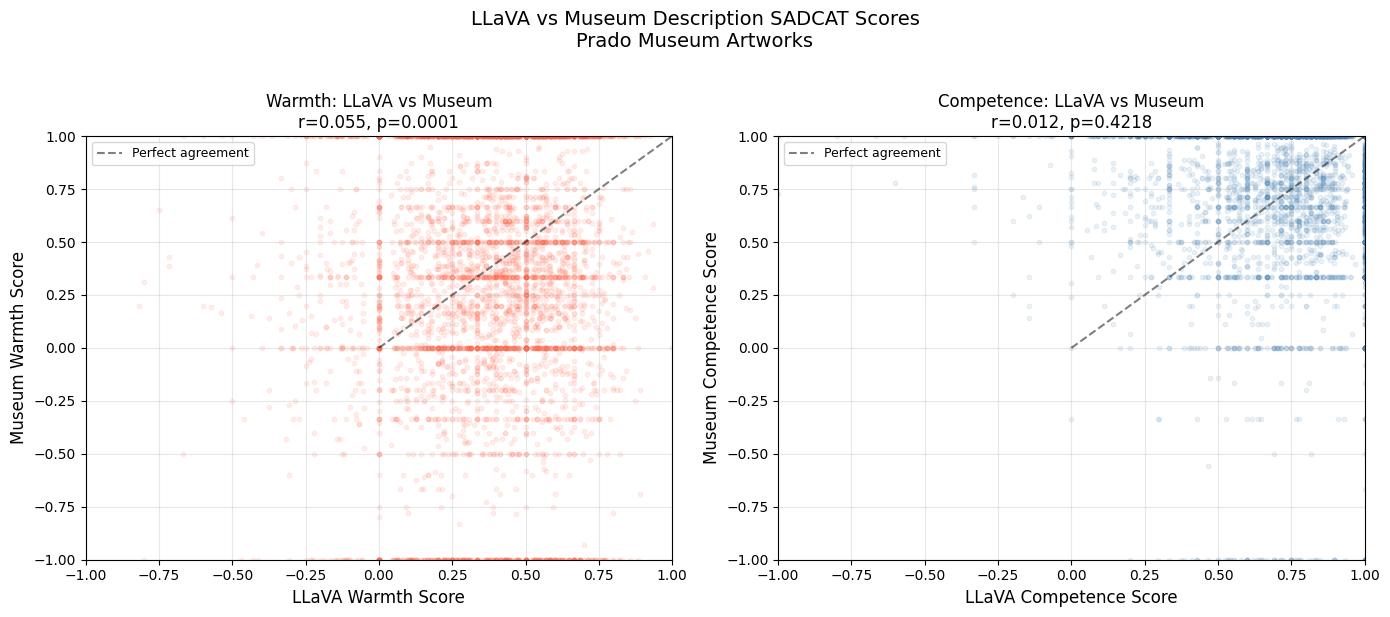

Plot saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot LLaVA vs Museum warmth
ax = axes[0]
ax.scatter(warm_combined['llava_warmth'], warm_combined['museum_warmth'],
           alpha=0.1, s=10, color='tomato')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect agreement')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel('LLaVA Warmth Score', fontsize=12)
ax.set_ylabel('Museum Warmth Score', fontsize=12)
ax.set_title(f'Warmth: LLaVA vs Museum\nr={corr_warm:.3f}, p={p_warm:.4f}', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Scatter plot LLaVA vs Museum competence
ax = axes[1]
ax.scatter(comp_combined['llava_competence'], comp_combined['museum_competence'],
           alpha=0.1, s=10, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect agreement')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel('LLaVA Competence Score', fontsize=12)
ax.set_ylabel('Museum Competence Score', fontsize=12)
ax.set_title(f'Competence: LLaVA vs Museum\nr={corr_comp:.3f}, p={p_comp:.4f}', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('LLaVA vs Museum Description SADCAT Scores\nPrado Museum Artworks', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/llava_vs_museum.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [12]:
# Load LLaVA scores
llava_scores = pd.read_csv(
    "/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/sadcat_scores_llava.csv"
)

# Recreate LLaVA group scores
elite_ids        = [402, 403, 406, 407, 408, 409]
nonelite_ids     = [358, 359, 360, 361, 364, 369, 370, 371, 372, 373, 376, 377, 380]
predatory_ids    = [206, 205, 208, 202, 216, 204, 194]
domesticated_ids = [217, 178, 215, 179, 176, 173, 182, 192]

elite_cats        = artwork_tags[artwork_tags['tag_id'].isin(elite_ids)]['cat_no'].unique()
nonelite_cats     = artwork_tags[artwork_tags['tag_id'].isin(nonelite_ids)]['cat_no'].unique()
predatory_cats    = artwork_tags[artwork_tags['tag_id'].isin(predatory_ids)]['cat_no'].unique()
domesticated_cats = artwork_tags[artwork_tags['tag_id'].isin(domesticated_ids)]['cat_no'].unique()

elite_scores        = llava_scores[llava_scores['cat_no'].isin(elite_cats)]
nonelite_scores     = llava_scores[llava_scores['cat_no'].isin(nonelite_cats)]
predatory_scores    = llava_scores[llava_scores['cat_no'].isin(predatory_cats)]
domesticated_scores = llava_scores[llava_scores['cat_no'].isin(domesticated_cats)]

print(f"Elite:        {len(elite_scores)}")
print(f"Non-Elite:    {len(nonelite_scores)}")
print(f"Predatory:    {len(predatory_scores)}")
print(f"Domesticated: {len(domesticated_scores)}")

Elite:        998
Non-Elite:    155
Predatory:    156
Domesticated: 1357


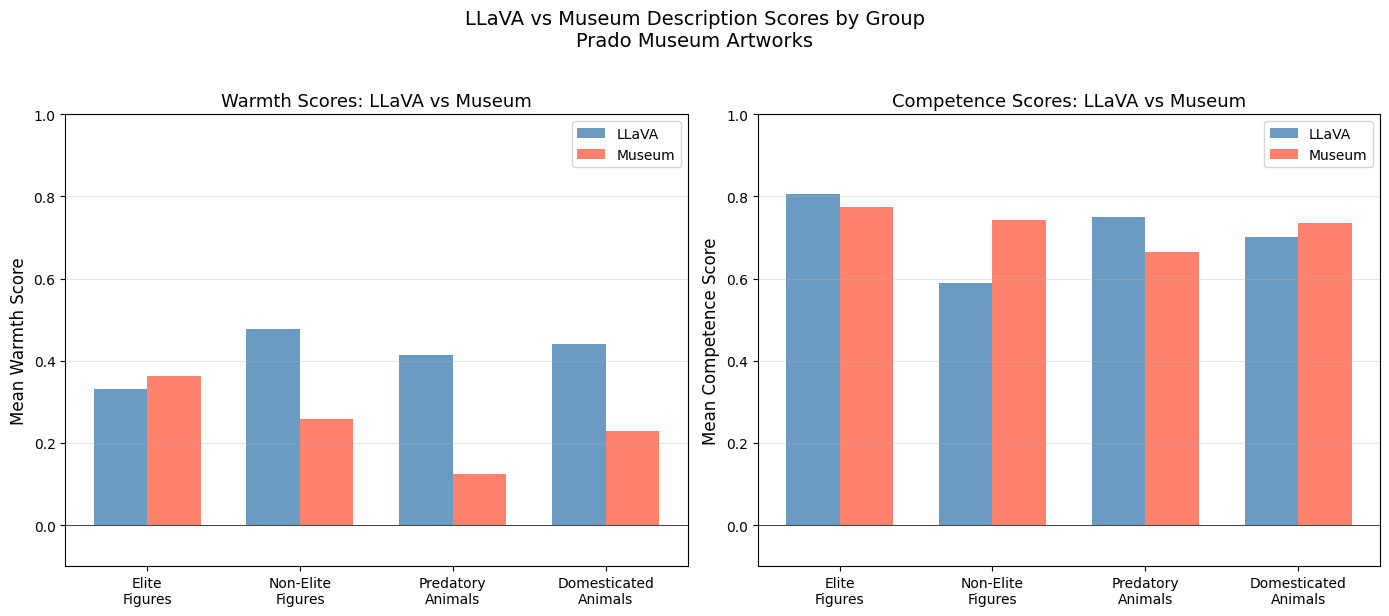

Plot saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

categories = ['Elite\nFigures', 'Non-Elite\nFigures', 'Predatory\nAnimals', 'Domesticated\nAnimals']

llava_warmth = [
    elite_scores['warmth_score'].mean(),
    nonelite_scores['warmth_score'].mean(),
    predatory_scores['warmth_score'].mean(),
    domesticated_scores['warmth_score'].mean()
]

museum_warmth = [
    elite_scores_m['dirmean_Warmth'].mean(),
    nonelite_scores_m['dirmean_Warmth'].mean(),
    predatory_scores_m['dirmean_Warmth'].mean(),
    domesticated_scores_m['dirmean_Warmth'].mean()
]

llava_comp = [
    elite_scores['competence_score'].mean(),
    nonelite_scores['competence_score'].mean(),
    predatory_scores['competence_score'].mean(),
    domesticated_scores['competence_score'].mean()
]

museum_comp = [
    elite_scores_m['dirmean_Competence'].mean(),
    nonelite_scores_m['dirmean_Competence'].mean(),
    predatory_scores_m['dirmean_Competence'].mean(),
    domesticated_scores_m['dirmean_Competence'].mean()
]

x = np.arange(len(categories))
width = 0.35

# Warmth comparison
ax = axes[0]
bars1 = ax.bar(x - width/2, llava_warmth, width, label='LLaVA', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, museum_warmth, width, label='Museum', color='tomato', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(-0.1, 1.0)
ax.set_ylabel('Mean Warmth Score', fontsize=12)
ax.set_title('Warmth Scores: LLaVA vs Museum', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linewidth=0.5)

# Competence comparison
ax = axes[1]
bars3 = ax.bar(x - width/2, llava_comp, width, label='LLaVA', color='steelblue', alpha=0.8)
bars4 = ax.bar(x + width/2, museum_comp, width, label='Museum', color='tomato', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(-0.1, 1.0)
ax.set_ylabel('Mean Competence Score', fontsize=12)
ax.set_title('Competence Scores: LLaVA vs Museum', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linewidth=0.5)

plt.suptitle('LLaVA vs Museum Description Scores by Group\nPrado Museum Artworks', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/home/agrupa-lab/agrupa/IE_capstones/Omar/outputs/llava_vs_museum_groups.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [14]:
from scipy.stats import linregress

print("=" * 60)
print("H1a: Linear Regression — LLaVA vs Museum Scores")
print("=" * 60)

# Warmth regression
slope_w, intercept_w, r_w, p_w, se_w = linregress(
    warm_combined['llava_warmth'],
    warm_combined['museum_warmth']
)
r2_w = r_w ** 2
print(f"\nWarmth:")
print(f"  R²={r2_w:.4f}, slope={slope_w:.3f}, intercept={intercept_w:.3f}, p={p_w:.4f}")

# Competence regression
slope_c, intercept_c, r_c, p_c, se_c = linregress(
    comp_combined['llava_competence'],
    comp_combined['museum_competence']
)
r2_c = r_c ** 2
print(f"\nCompetence:")
print(f"  R²={r2_c:.4f}, slope={slope_c:.3f}, intercept={intercept_c:.3f}, p={p_c:.4f}")

print("\nInterpretation:")
if p_w < 0.05:
    print(f"  Warmth model significant (p={p_w:.4f}), R²={r2_w:.4f} — very weak fit")
else:
    print(f"  Warmth model not significant (p={p_w:.4f})")

if p_c < 0.05:
    print(f"  Competence model significant (p={p_c:.4f}), R²={r2_c:.4f} — very weak fit")
else:
    print(f"  Competence model not significant (p={p_c:.4f})")

H1a: Linear Regression — LLaVA vs Museum Scores

Warmth:
  R²=0.0030, slope=0.134, intercept=0.270, p=0.0001

Competence:
  R²=0.0001, slope=0.017, intercept=0.744, p=0.4218

Interpretation:
  Warmth model significant (p=0.0001), R²=0.0030 — very weak fit
  Competence model not significant (p=0.4218)
